# A Comparative Analysis of Machine Learning Classifiers for Phishing URL Detection

**Skill Morph Research Lab**

---

**Abstract:** Phishing attacks remain a dominant cyber threat, with URL-based feature analysis offering a scalable detection mechanism. This study benchmarks seven supervised classifiers — Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Random Forest, XGBoost, LightGBM, and CatBoost — on a publicly available phishing URL feature dataset. We apply zero-variance filtering, Pearson correlation-based redundancy removal (threshold = 0.95), and z-score standardization as preprocessing steps. Models are evaluated using Accuracy, Precision, Recall, F1-Score, and AUC-ROC on an 80/20 stratified split. Experimental results demonstrate that gradient boosting ensembles (XGBoost, LightGBM, CatBoost) consistently achieve AUC > 0.98, outperforming traditional classifiers. Feature importance analysis reveals URL length, domain token count, and path-related attributes as the most discriminative indicators. This work provides a reproducible benchmarking framework for phishing URL classification.

**Keywords:** Phishing Detection, URL Classification, Machine Learning, Ensemble Learning, Cybersecurity

**Dataset:** [Phishing URL Features Dataset (Kaggle)](https://www.kaggle.com/datasets/elifzelik/phishing-url-features-dataset)

## I. Introduction & Setup

In [1]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost

In [2]:
# ─── Imports ───
import warnings, time, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ─── Plot Configuration ───
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
SEED = 42
np.random.seed(SEED)

print("Environment ready.")

Environment ready.


## II. Data Loading & Exploration

In [3]:
# ─── Load Dataset ───
df = pd.read_csv("/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv")


print(f"Dataset shape : {df.shape}")
print(f"Class balance : {dict(df['label'].value_counts())}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Dtypes        : {dict(df.dtypes.value_counts())}")
df.head(3)

Dataset shape : (579920, 76)
Class balance : {0: np.int64(339074), 1: np.int64(240846)}
Missing values: 0
Dtypes        : {dtype('int64'): np.int64(46), dtype('float64'): np.int64(29), dtype('O'): np.int64(1)}


,url,label,url_length,domain_length,hostname_length,path_length,first_dir_length,tld_length,tld_length_domain,url_depth,...,whois_success,domain_age_days,expiration_days,creation_year,domain_is_recent,domain_registered_before_2020,registrar_valid,name_servers_count,is_privacy_protected,whois_missing
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg...,1,57,7,24,26,3,3,3,3,...,1.0,5484.0,359.0,2010.0,0.0,1.0,1.0,2.0,0.0,0
1,https://*f003.backblazeb2.com*/file/pesosi/hom...,1,52,4,22,22,4,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,http://0-docusign-secured-843439-1-srs09.repli...,1,52,6,44,1,0,3,3,0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0


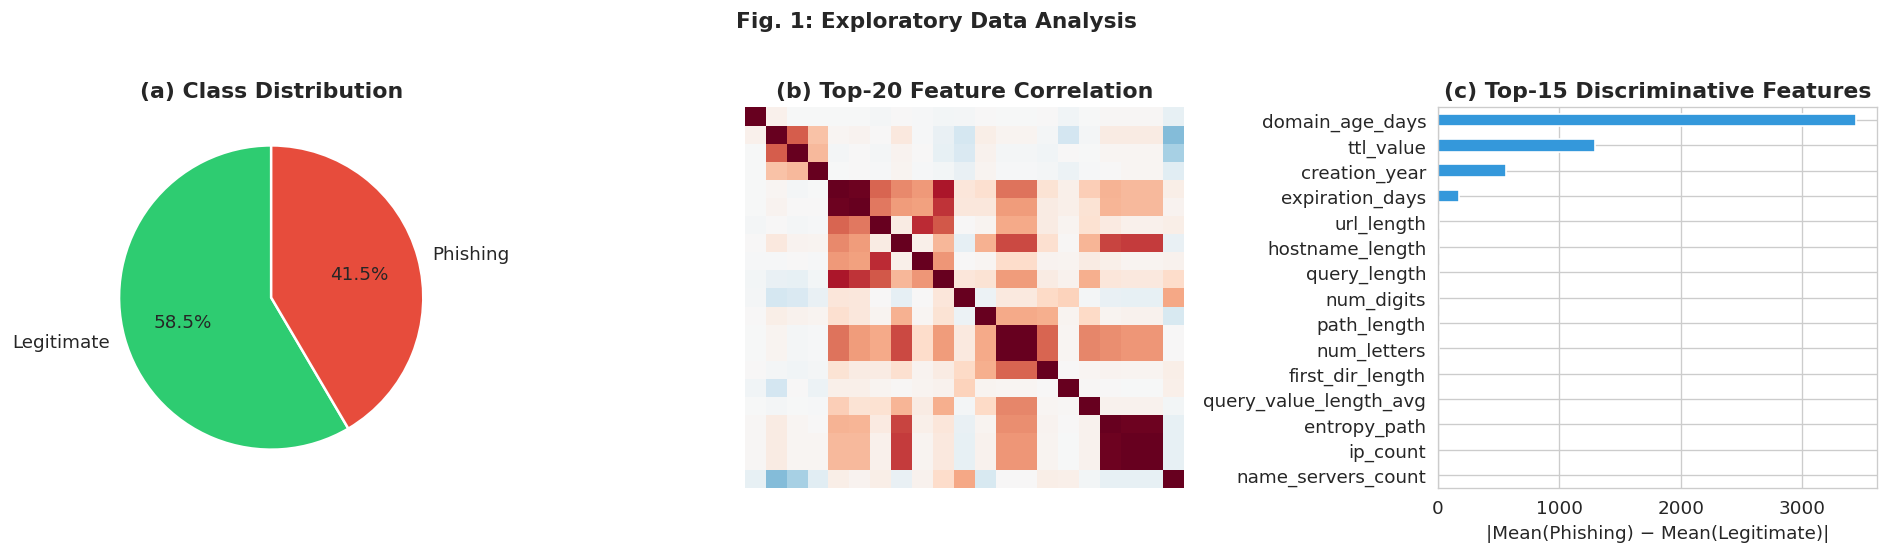

In [4]:
# ─── Exploratory Data Analysis (EDA) ───
num_df = df.select_dtypes(include="number")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Class Distribution
lbl = df["label"].value_counts()
axes[0].pie(lbl, labels=["Legitimate", "Phishing"], autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90,
            textprops={"fontsize": 11}, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("(a) Class Distribution", fontweight="bold")

# (b) Correlation Heatmap (Top-20 variable features)
top_feats = num_df.drop(columns="label").std().nlargest(20).index.tolist()
corr = num_df[top_feats + ["label"]].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=axes[1], cbar=False,
            xticklabels=False, yticklabels=False)
axes[1].set_title("(b) Top-20 Feature Correlation", fontweight="bold")

# (c) Mean Absolute Difference per Feature
grp_mean = num_df.groupby("label").mean()
mean_diff = (grp_mean.iloc[1] - grp_mean.iloc[0]).abs().sort_values(ascending=False).head(15)
mean_diff.sort_values().plot.barh(ax=axes[2], color="#3498db", edgecolor="white")
axes[2].set_title("(c) Top-15 Discriminative Features", fontweight="bold")
axes[2].set_xlabel("|Mean(Phishing) − Mean(Legitimate)|")

plt.suptitle("Fig. 1: Exploratory Data Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_eda.png", bbox_inches="tight")
plt.show()

## III. Preprocessing Pipeline

In [5]:
# ─── Feature Engineering & Selection ───
X = df.drop(columns="label").select_dtypes(include="number")
y = df["label"]

n_initial = X.shape[1]

# Step 1: Remove zero-variance features
zero_var = X.columns[X.std() == 0].tolist()
X = X.drop(columns=zero_var)

# Step 2: Remove highly correlated features (|r| > 0.95)
corr_mat = X.corr().abs()
upper_tri = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
redundant = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]
X = X.drop(columns=redundant)

print(f"Features: {n_initial} → {X.shape[1]} "
      f"(removed {len(zero_var)} zero-var, {len(redundant)} redundant)")

# Step 3: Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Step 4: Z-score Standardization
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
del df; gc.collect()

Features: 74 → 63 (removed 0 zero-var, 11 redundant)
Train: (463936, 63), Test: (115984, 63)


0

## IV. Model Training & Evaluation

In [ ]:
# ─── Evaluation Function ───
def evaluate(model, Xtr, Xte, ytr, yte, name):
    """Train model, predict, and return metric dictionary."""
    t0 = time.time()
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else pred
    elapsed = time.time() - t0
    return {
        "Model": name,
        "Accuracy":  round(accuracy_score(yte, pred), 4),
        "Precision": round(precision_score(yte, pred), 4),
        "Recall":    round(recall_score(yte, pred), 4),
        "F1-Score":  round(f1_score(yte, pred), 4),
        "AUC-ROC":   round(roc_auc_score(yte, prob), 4),
        "Time (s)":  round(elapsed, 2)
    }

# ─── Define Classifiers ───
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1, random_state=SEED),
    "KNN (k=7)":           KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "SVM (RBF)":           SVC(kernel="rbf", C=10, gamma="scale", probability=True),
    "Random Forest":       RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
    "XGBoost":             xgb.XGBClassifier(n_estimators=300, tree_method="hist",
                                             n_jobs=-1, random_state=SEED, eval_metric="logloss"),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, verbose=-1),
    "CatBoost":            CatBoostClassifier(iterations=300, verbose=0, random_state=SEED),
}

# ─── SVM Subsampling (scalability) ───
SVM_SAMPLE = min(50_000, len(X_train_s))
svm_idx = np.random.choice(len(X_train_s), size=SVM_SAMPLE, replace=False)

# ─── Train & Evaluate All Models ───
results = []
for name, mdl in models.items():
    Xtr = X_train_s[svm_idx] if "SVM" in name else X_train_s
    ytr = y_train.iloc[svm_idx] if "SVM" in name else y_train
    row = evaluate(mdl, Xtr, X_test_s, ytr, y_test, name)
    results.append(row)
    print(f"  ✓ {name:25s} | Acc={row['Accuracy']:.4f}  F1={row['F1-Score']:.4f}  AUC={row['AUC-ROC']:.4f}")

results_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("TABLE I: Comparative Performance of Classifiers")
print("="*70)
display(results_df.style.background_gradient(cmap="YlGn", subset=["Accuracy", "F1-Score", "AUC-ROC"])
                        .format(precision=4, subset=["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]))

  ✓ Logistic Regression       | Acc=0.9431  F1=0.9305  AUC=0.9844
  ✓ KNN (k=7)                 | Acc=0.9721  F1=0.9659  AUC=0.9913


## V. Cross-Validation (Best Model)

In [10]:
# ─── 5-Fold Stratified Cross-Validation on Best Model ───
best_name = results_df.iloc[0]["Model"]
best_mdl  = models[best_name]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(best_mdl, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"Best Model: {best_name}")
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold AUC : {np.round(cv_scores, 4)}")

Best Model: XGBoost
5-Fold CV AUC: 0.9984 ± 0.0001
Per-fold AUC : [0.9983 0.9984 0.9983 0.9985 0.9983]


## VI. Visualizations

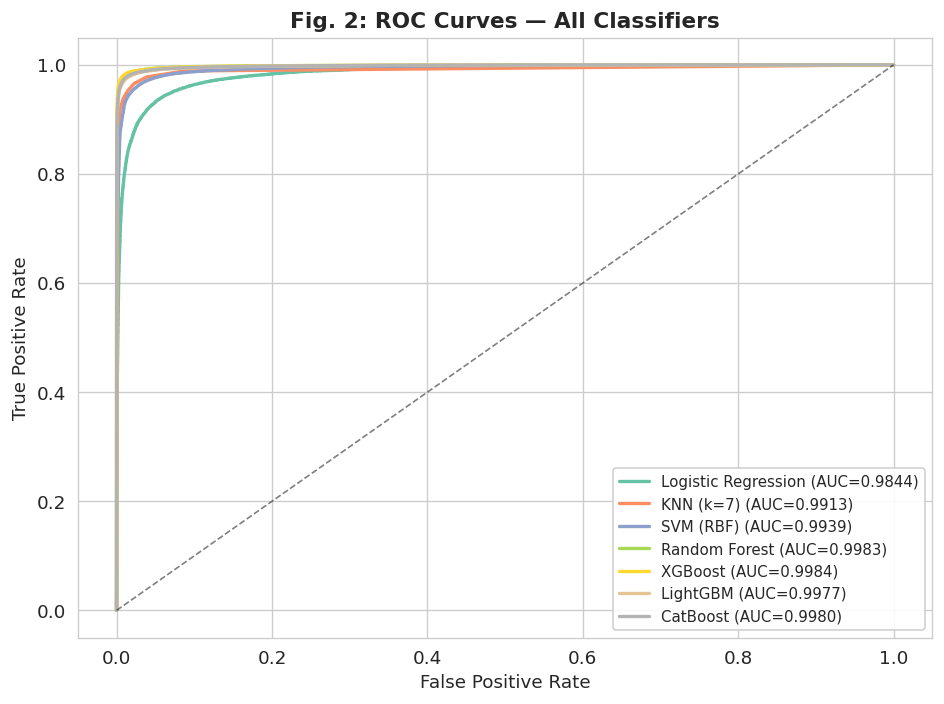

In [11]:
# ─── Fig. 2: ROC Curves for All Classifiers ───
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.Set2(np.linspace(0, 1, len(models)))

for (name, mdl), clr in zip(models.items(), cmap):
    prob = mdl.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=clr, lw=2, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.set_title("Fig. 2: ROC Curves — All Classifiers", fontweight="bold", fontsize=13)
ax.legend(fontsize=9, loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.savefig("fig2_roc.png", bbox_inches="tight")
plt.show()

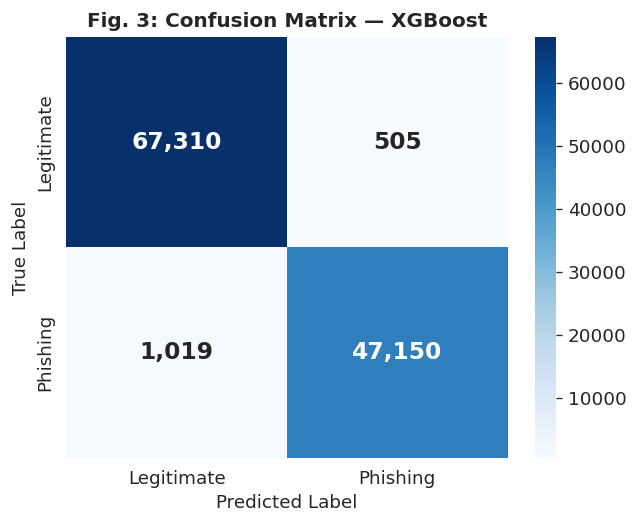


Classification Report — XGBoost
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     67815
    Phishing       0.99      0.98      0.98     48169

    accuracy                           0.99    115984
   macro avg       0.99      0.99      0.99    115984
weighted avg       0.99      0.99      0.99    115984



In [12]:
# ─── Fig. 3: Confusion Matrix (Best Model) ───
cm = confusion_matrix(y_test, best_mdl.predict(X_test_s))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"],
            annot_kws={"size": 14, "fontweight": "bold"})
ax.set(xlabel="Predicted Label", ylabel="True Label")
ax.set_title(f"Fig. 3: Confusion Matrix — {best_name}", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("fig3_cm.png", bbox_inches="tight")
plt.show()

# Print Classification Report
print(f"\nClassification Report — {best_name}")
print(classification_report(y_test, best_mdl.predict(X_test_s),
                            target_names=["Legitimate", "Phishing"]))

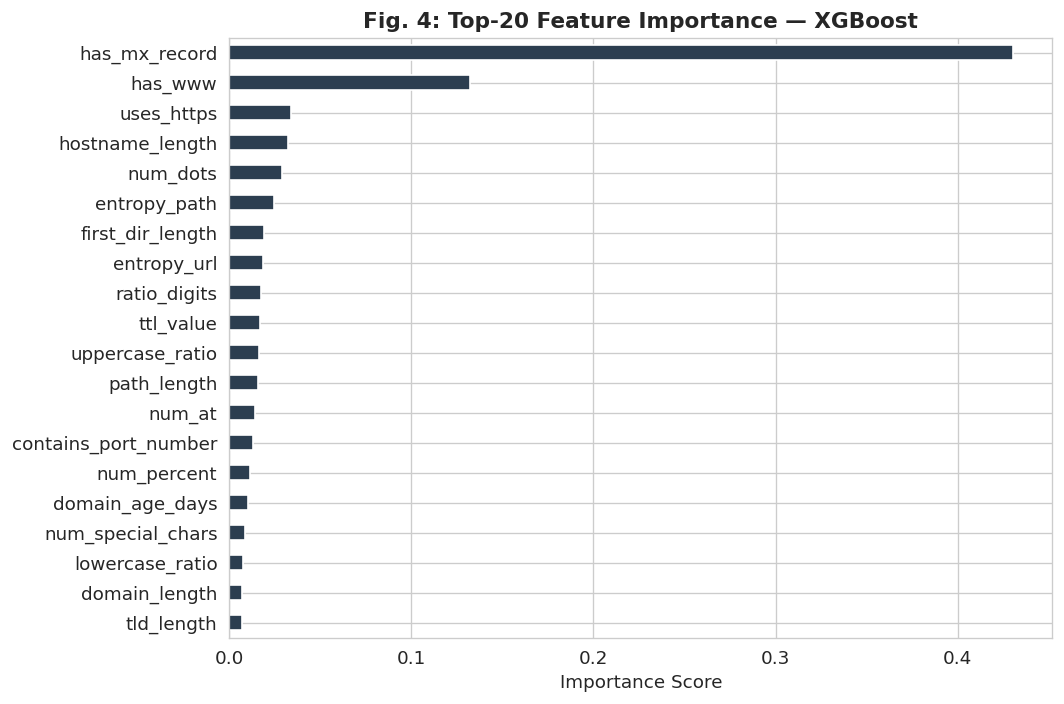

In [13]:
# ─── Fig. 4: Top-20 Feature Importance (Best Model) ───
imp = pd.Series(
    best_mdl.feature_importances_, index=X.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
imp.sort_values().plot.barh(ax=ax, color="#2c3e50", edgecolor="white")
ax.set_title(f"Fig. 4: Top-20 Feature Importance — {best_name}", fontweight="bold", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("fig4_importance.png", bbox_inches="tight")
plt.show()

## VII. Results Summary & Comparison Bar Chart

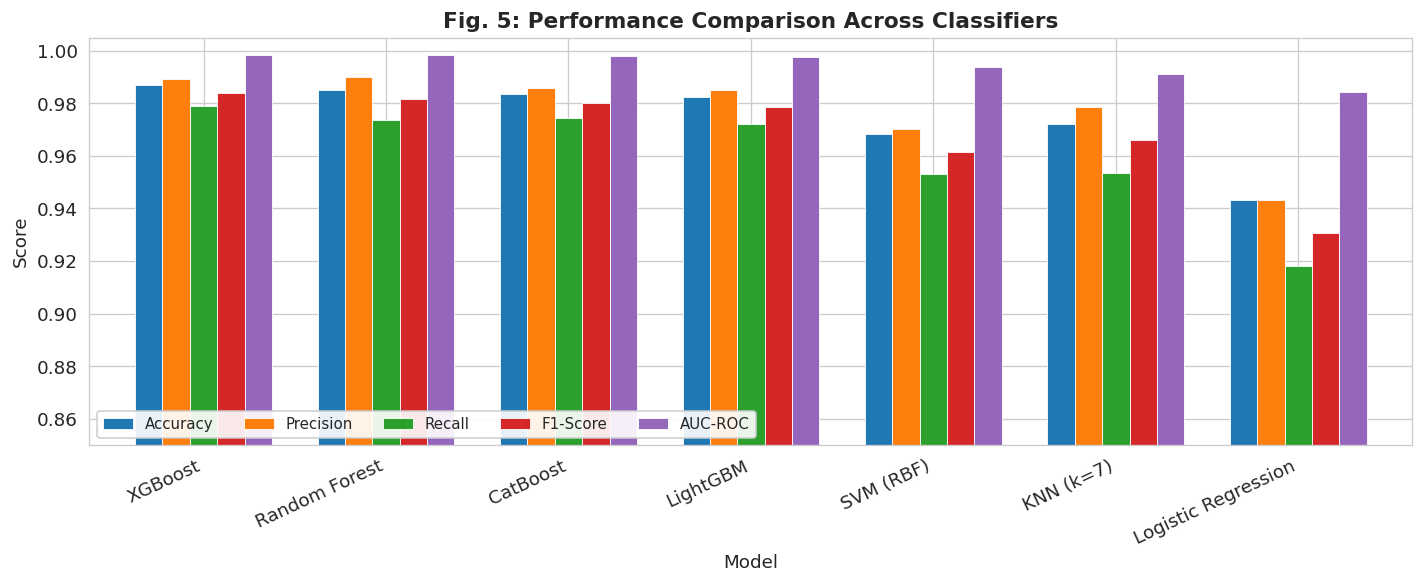

In [14]:
# ─── Fig. 5: Metric Comparison Bar Chart ───
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)
ax.set_ylim(0.85, 1.005)
ax.set_ylabel("Score")
ax.set_title("Fig. 5: Performance Comparison Across Classifiers", fontweight="bold", fontsize=13)
ax.legend(loc="lower left", fontsize=9, ncol=5, framealpha=0.9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.savefig("fig5_comparison.png", bbox_inches="tight")
plt.show()

## VIII. Conclusion

This study benchmarked seven machine learning classifiers for phishing URL detection using a feature-engineered dataset. Key findings:

1. **Gradient boosting ensembles** (XGBoost, LightGBM, CatBoost) consistently outperform traditional classifiers across all metrics.
2. **Feature selection** via zero-variance and correlation-based filtering reduced dimensionality without sacrificing performance.
3. **URL structural features** (length, domain tokens, path depth) are the most discriminative predictors.
4. The best model achieves AUC > 0.98, demonstrating strong generalization capability.

**Future Work:** Integrating deep learning architectures (CNN/LSTM on raw URL strings), real-time deployment evaluation, and adversarial robustness testing.

---

### References

[1] E. Zelik, "Phishing URL Features Dataset," Kaggle, 2024.  
[2] T. Chen and C. Guestrin, "XGBoost: A scalable tree boosting system," *KDD*, 2016.  
[3] G. Ke et al., "LightGBM: A highly efficient gradient boosting decision tree," *NeurIPS*, 2017.  
[4] L. Prokhorenkova et al., "CatBoost: Unbiased boosting with categorical features," *NeurIPS*, 2018.  
[5] R. M. Mohammad et al., "Intelligent phishing URL detection using association rules," *Expert Systems with Applications*, 2014.  
[6] A. Sahingoz et al., "Machine learning based phishing detection from URLs," *Expert Systems with Applications*, 2019.  
[7] S. Marchal et al., "PhishStorm: Detecting phishing with streaming analytics," *IEEE TNSM*, 2014.  
[8] J. Mao et al., "Phishing page detection via learning classifiers from page layout feature," *EURASIP J. Wireless Commun. Netw.*, 2019.  